# gp 优化模块


## ramped half-and-half


In [1]:
import numpy as np
import pandas as pd

from src.evaluation.fitness import compute_forward_returns, make_fitness
from src.gp.engine import GPConfig, ramped_half_and_half, random_tree, run_gp
from src.gp.evaluator import to_wide


grow-only  | 深度 2~6 (均值3.5) | 节点数 3~26 (均值6.6)
ramped     | 深度 1~6 (均值3.0) | 节点数 2~41 (均值7.1)


<Axes: >

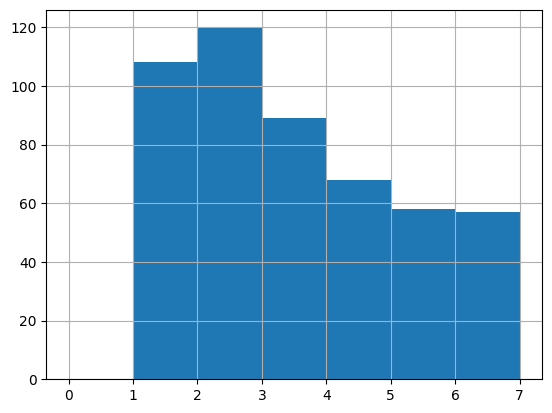

In [2]:
cfg = GPConfig()
grow_only = [random_tree(cfg.max_depth, cfg.min_depth) for _ in range(500)]
ramped = ramped_half_and_half(500, cfg.min_depth, cfg.max_depth)


def describe(pop, name):
    d = pd.Series([t.depth() for t in pop])
    s = pd.Series([t.size() for t in pop])
    print(
        f"{name:10s} | 深度 {d.min()}~{d.max()} (均值{d.mean():.1f}) "
        f"| 节点数 {s.min()}~{s.max()} (均值{s.mean():.1f})"
    )


describe(grow_only, "grow-only")
describe(ramped, "ramped")

# 想看分布形状就画直方图：
pd.Series([t.depth() for t in ramped]).hist(bins=range(0, cfg.max_depth + 2))

## parsimony 惩罚限制


In [3]:
# 复用之前的迷你合成数据（20 只 × 60 天）
dates = pd.date_range("2024-01-01", periods=60, freq="B")
codes = [f"s{i:02d}" for i in range(20)]
idx = pd.MultiIndex.from_product([dates, codes], names=["date", "code"])
rng = np.random.default_rng(0)
prices = pd.DataFrame(
    {
        c: rng.random(len(idx)) * 100 + 10
        for c in ["open", "high", "low", "close", "volume", "amount"]
    },
    index=idx,
)
wide = to_wide(prices)
fwd = compute_forward_returns(wide["close"], period=5)

cfg = GPConfig(population_size=40, generations=8, max_depth=6, min_depth=2)

for alpha in [0.0, 0.005]:
    fn = make_fitness(wide, fwd, parsimony=alpha)
    best_tree, best_score = run_gp(fn, cfg)[0]
    print(f"α={alpha}: 最佳 size={best_tree.size():2d}  score={best_score:.4f}")


Gen   0 | best=4.3691 | mean=0.0557 | expr=neg(rank(close))
Gen   1 | best=4.3691 | mean=1.1196 | expr=neg(rank(close))
Gen   2 | best=4.3691 | mean=3.3056 | expr=neg(rank(close))
Gen   3 | best=4.3691 | mean=4.1267 | expr=neg(rank(close))
Gen   4 | best=4.3691 | mean=4.3691 | expr=neg(rank(close))
Gen   5 | best=4.3691 | mean=3.8055 | expr=neg(rank(close))
Gen   6 | best=4.3691 | mean=4.2614 | expr=neg(rank(close))
Gen   7 | best=4.3691 | mean=4.2349 | expr=neg(rank(close))
α=0.0: 最佳 size= 3  score=4.3691
Gen   0 | best=4.3541 | mean=0.0268 | expr=log(abs(close))
Gen   1 | best=4.3591 | mean=0.7063 | expr=log(close)
Gen   2 | best=4.3641 | mean=2.0732 | expr=close
Gen   3 | best=4.3641 | mean=3.7386 | expr=close
Gen   4 | best=4.3641 | mean=4.1483 | expr=close
Gen   5 | best=4.3641 | mean=4.2569 | expr=close
Gen   6 | best=4.3641 | mean=4.3641 | expr=close
Gen   7 | best=4.3641 | mean=4.2568 | expr=close
α=0.005: 最佳 size= 1  score=4.3641


很不幸地，这里的实验和我们的预期恰好相反，更大的约束反而size更大。

这就意味着，大树的原始 ICIR 更高，惩罚根本没有效果。而且我们 alpha 的尺度在 ICIR 面前未必够用。

另外，这里手贱没有加随机种子，两次实验其实并不能直接对比...下面重新跑。


In [4]:
import random

cfg = GPConfig(population_size=40, generations=8, max_depth=6, min_depth=2)

for alpha in [0.0, 0.05, 0.2]:
    random.seed(0)
    np.random.seed(0)  # 同种子 → 唯一变量就是 α，隔离 parsimony
    fn = make_fitness(wide, fwd, parsimony=alpha)
    best_tree, best_score = run_gp(fn, cfg)[0]
    raw = best_score + alpha * best_tree.size()  # 还原未罚的 |ICIR|，公平比因子质量
    print(f"α={alpha:<5} size={best_tree.size():2d}  raw|ICIR|={raw:.3f}  {best_tree}")

Gen   0 | best=4.3691 | mean=-0.0387 | expr=neg(close)
Gen   1 | best=4.3691 | mean=1.2261 | expr=neg(close)
Gen   2 | best=4.3691 | mean=2.4305 | expr=neg(close)
Gen   3 | best=4.3691 | mean=3.9588 | expr=neg(close)
Gen   4 | best=4.3691 | mean=4.2603 | expr=neg(close)
Gen   5 | best=4.3691 | mean=4.3691 | expr=neg(close)
Gen   6 | best=4.3691 | mean=4.1553 | expr=neg(close)
Gen   7 | best=4.3691 | mean=4.2605 | expr=neg(close)
α=0.0   size= 2  raw|ICIR|=4.369  neg(close)
Gen   0 | best=4.2691 | mean=-0.2550 | expr=neg(close)
Gen   1 | best=4.3191 | mean=0.9585 | expr=close
Gen   2 | best=4.3191 | mean=2.4509 | expr=close
Gen   3 | best=4.3191 | mean=3.8702 | expr=close
Gen   4 | best=4.3191 | mean=4.2090 | expr=close
Gen   5 | best=4.3191 | mean=3.9702 | expr=close
Gen   6 | best=4.3191 | mean=4.1041 | expr=close
Gen   7 | best=4.3191 | mean=4.2105 | expr=close
α=0.05  size= 1  raw|ICIR|=4.369  close
Gen   0 | best=3.9691 | mean=-0.9037 | expr=neg(close)
Gen   1 | best=4.1691 | mean=

可以看到，节点数量是有效被限制了的，而且并没有丢失预测能力。
